# ISPRA Rifiuti Urbani — costi e performance per comune (v1)

**Domanda civica:** I territori che producono meno rifiuti urbani o raccolgono meglio spendono anche meno?

Questo notebook lavora sul perimetro in cui il join tra tre dataset ISPRA regge davvero: RU base (kg prodotti, % RD), costi per chilogrammo e costi per abitante, sullo stesso `codice_comune_istat x anno`.


In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


def _find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "candidates").exists() and (p / "out").exists():
            return p
    return Path.cwd().parents[2]


ROOT = _find_repo_root()
BASE = ROOT / "out" / "data" / "mart" / "ispra_ru_base"

available_years = sorted([int(p.parent.name) for p in BASE.glob("*/mart_cross_comuni.parquet")])
print(f"Anni disponibili: {available_years}")

paths = [(BASE / str(y) / "mart_cross_comuni.parquet").as_posix() for y in available_years]
union_sql = " UNION ALL ".join([f"SELECT * FROM read_parquet('{p}')" for p in paths])

con = duckdb.connect()

Anni disponibili: [2020, 2023, 2024]


## 1. Copertura del join A + B + C

Prima di leggere costi e performance: su quanti comuni i tre dataset si incrociano davvero?


In [2]:
coverage = con.execute(
    f"""WITH t AS ({union_sql})
    SELECT
        anno,
        COUNT(*) AS comuni_ru,
        SUM(CASE WHEN join_b_ok AND join_c_ok THEN 1 ELSE 0 END) AS comuni_join,
        ROUND(100.0 * SUM(CASE WHEN join_b_ok AND join_c_ok THEN 1 ELSE 0 END) / COUNT(*), 1) AS copertura_pct
    FROM t GROUP BY anno ORDER BY anno"""
).df()
coverage

,anno,comuni_ru,comuni_join,copertura_pct
0,2020,7628,"4,397.00",57.60
1,2023,7669,"6,250.00",81.50
2,2024,7671,"6,477.00",84.40


## 2. Trend delle metriche chiave

Tre snapshot disponibili: 2020, 2023, 2024.


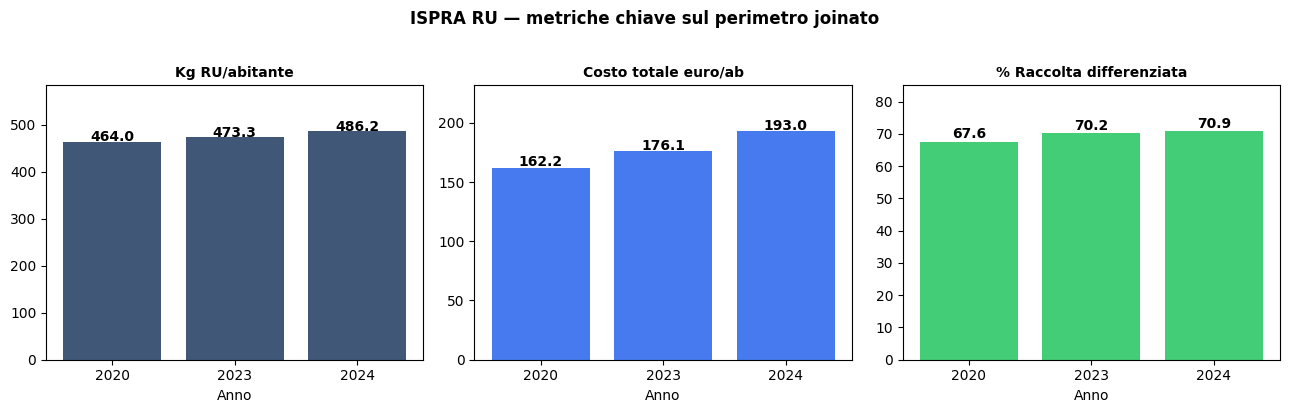

,anno,kg_ab,euro_ab,pct_rd
0,2020,464.00,162.20,67.60
1,2023,473.30,176.10,70.20
2,2024,486.20,193.00,70.90


In [3]:
trend = con.execute(
    f"""WITH t AS ({union_sql})
    SELECT anno,
           ROUND(AVG(kg_ru_per_abitante_calc), 1) AS kg_ab,
           ROUND(AVG(costo_totale_euro_ab), 1) AS euro_ab,
           ROUND(AVG(percentuale_rd), 1) AS pct_rd
    FROM t WHERE join_b_ok AND join_c_ok
    GROUP BY anno ORDER BY anno"""
).df()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pairs = [
    ("kg_ab", "Kg RU/abitante", "#1E3A5F"),
    ("euro_ab", "Costo totale euro/ab", "#2563EB"),
    ("pct_rd", "% Raccolta differenziata", "#22C55E"),
]
for ax, (col, label, color) in zip(axes, pairs):
    ax.bar(trend["anno"].astype(str), trend[col], color=color, alpha=0.85)
    for i, v in enumerate(trend[col]):
        ax.text(i, float(v) + 1, str(v), ha="center", fontsize=10, fontweight="bold")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylim(0, float(trend[col].max()) * 1.2)
    ax.set_xlabel("Anno")
plt.suptitle(
    "ISPRA RU — metriche chiave sul perimetro joinato", fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()
trend

## 3. Relazione tra performance e costo (2024)

Sul perimetro joinato 2024: esiste una relazione osservabile tra kg prodotti, % RD e costo per abitante?


Correlazioni 2024:
                         kg_ru_per_abitante_calc  costo_totale_euro_ab  \
kg_ru_per_abitante_calc                     1.00                  0.61   
costo_totale_euro_ab                        0.61                  1.00   
percentuale_rd                             -0.09                 -0.29   

                         percentuale_rd  
kg_ru_per_abitante_calc           -0.09  
costo_totale_euro_ab              -0.29  
percentuale_rd                     1.00  


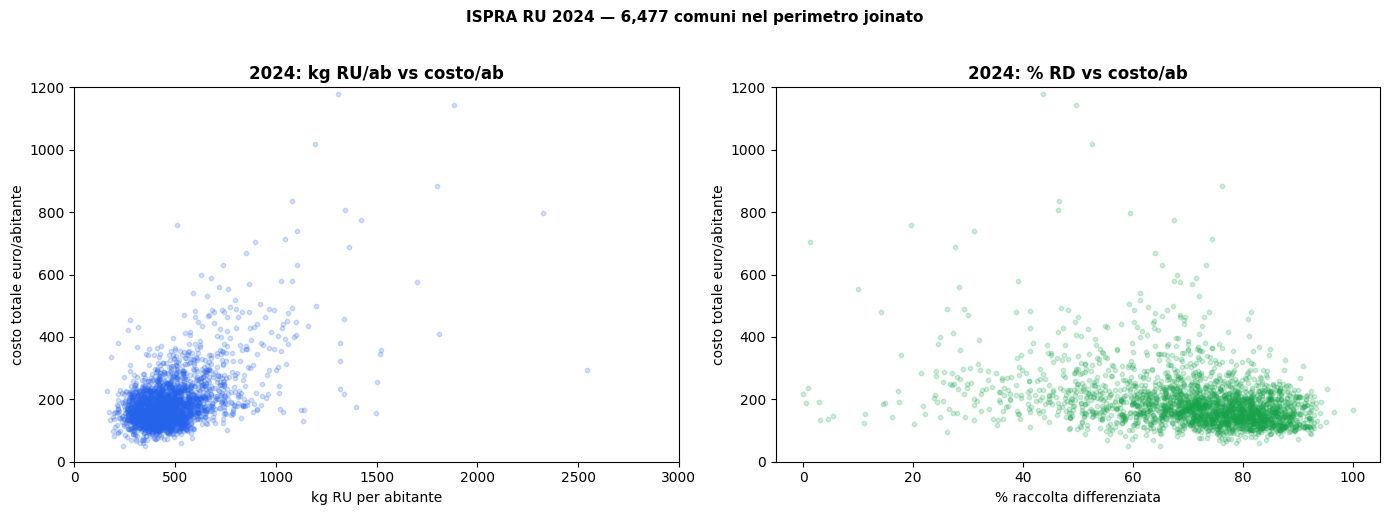

In [4]:
joined_2024 = con.execute(
    f"""WITH t AS ({union_sql})
    SELECT * FROM t WHERE anno = 2024 AND join_b_ok AND join_c_ok"""
).df()

corr = (
    joined_2024[["kg_ru_per_abitante_calc", "costo_totale_euro_ab", "percentuale_rd"]]
    .corr()
    .round(3)
)
print("Correlazioni 2024:")
print(corr)

sample = joined_2024.sample(min(len(joined_2024), 2500), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(
    sample["kg_ru_per_abitante_calc"],
    sample["costo_totale_euro_ab"],
    alpha=0.2,
    s=10,
    color="#2563EB",
)
axes[0].set_title("2024: kg RU/ab vs costo/ab", fontweight="bold")
axes[0].set_xlabel("kg RU per abitante")
axes[0].set_ylabel("costo totale euro/abitante")
axes[0].set_xlim(0, 3000)
axes[0].set_ylim(0, 1200)
axes[1].scatter(
    sample["percentuale_rd"], sample["costo_totale_euro_ab"], alpha=0.2, s=10, color="#16A34A"
)
axes[1].set_title("2024: % RD vs costo/ab", fontweight="bold")
axes[1].set_xlabel("% raccolta differenziata")
axes[1].set_ylabel("costo totale euro/abitante")
axes[1].set_ylim(0, 1200)
plt.suptitle(
    f"ISPRA RU 2024 — {len(joined_2024):,} comuni nel perimetro joinato",
    fontsize=11,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

## 4. Vista regionale (2024)

Aggregazione per regione: media costo/ab e % RD sui comuni nel perimetro joinato.


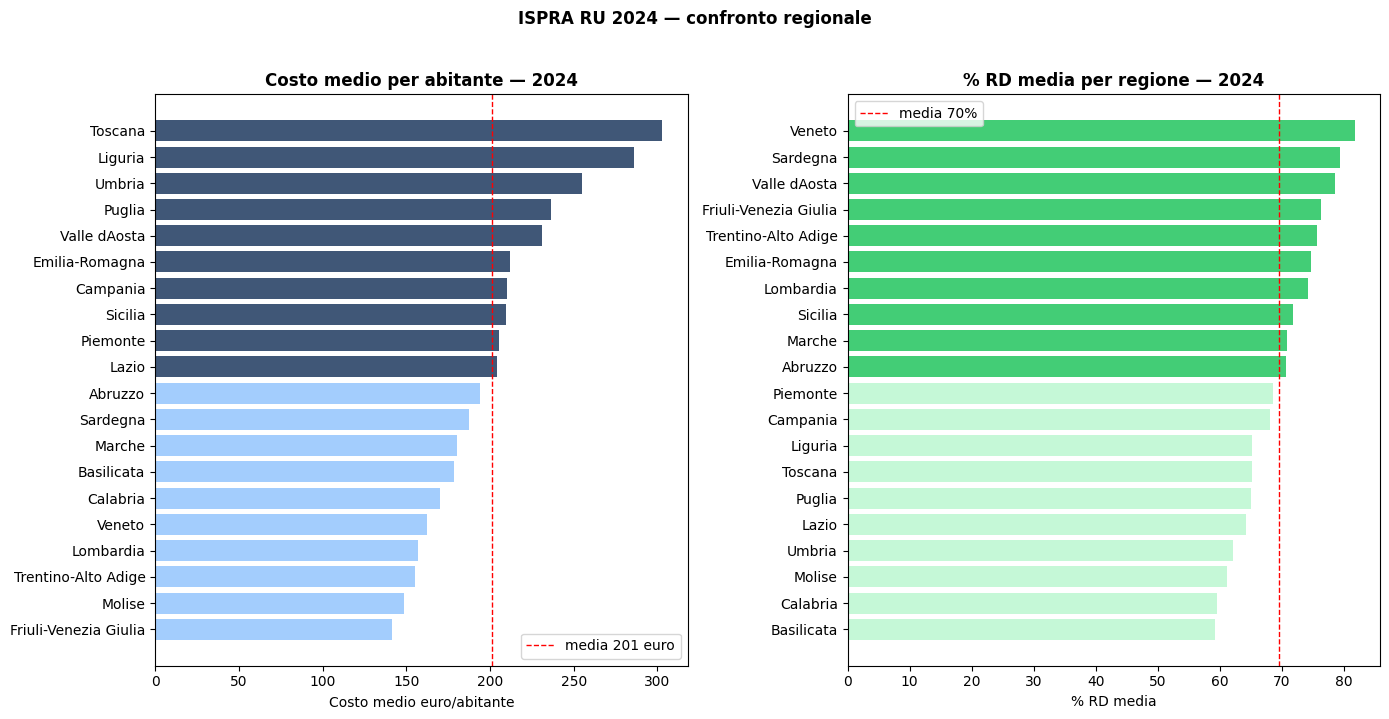

,regione,comuni,kg_ab,euro_ab,pct_rd
0,Toscana,251,590.10,302.80,65.10
1,Liguria,223,553.70,286.00,65.10
2,Umbria,78,531.70,254.80,62.10
3,Puglia,178,466.60,236.20,65.00
4,Valle dAosta,1,500.30,231.00,78.60
5,Emilia-Romagna,325,685.40,211.70,74.60
6,Campania,466,394.90,210.20,68.00
7,Sicilia,249,388.00,209.40,71.70
8,Piemonte,1067,521.90,205.40,68.50
9,Lazio,304,391.40,204.00,64.20


In [5]:
regioni = con.execute(
    f"""WITH t AS ({union_sql})
    SELECT regione,
           COUNT(*) AS comuni,
           ROUND(AVG(kg_ru_per_abitante_calc), 1) AS kg_ab,
           ROUND(AVG(costo_totale_euro_ab), 1) AS euro_ab,
           ROUND(AVG(percentuale_rd), 1) AS pct_rd
    FROM t WHERE anno = 2024 AND join_b_ok AND join_c_ok
    GROUP BY regione ORDER BY euro_ab DESC"""
).df()

media_euro = regioni["euro_ab"].mean()
media_rd = regioni["pct_rd"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors_e = ["#1E3A5F" if v >= media_euro else "#93C5FD" for v in regioni["euro_ab"]]
axes[0].barh(regioni["regione"][::-1], regioni["euro_ab"][::-1], color=colors_e[::-1], alpha=0.85)
axes[0].axvline(
    media_euro, color="red", linestyle="--", linewidth=1, label=f"media {media_euro:.0f} euro"
)
axes[0].set_xlabel("Costo medio euro/abitante")
axes[0].set_title("Costo medio per abitante — 2024", fontweight="bold")
axes[0].legend()
reg_rd = regioni.sort_values("pct_rd", ascending=False)
colors_r = ["#22C55E" if v >= media_rd else "#BBF7D0" for v in reg_rd["pct_rd"]]
axes[1].barh(reg_rd["regione"][::-1], reg_rd["pct_rd"][::-1], color=colors_r[::-1], alpha=0.85)
axes[1].axvline(media_rd, color="red", linestyle="--", linewidth=1, label=f"media {media_rd:.0f}%")
axes[1].set_xlabel("% RD media")
axes[1].set_title("% RD media per regione — 2024", fontweight="bold")
axes[1].legend()
plt.suptitle("ISPRA RU 2024 — confronto regionale", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
regioni

## 5. Casi notevoli

Tre tagli: costo molto alto, costo alto con pochi kg, alta RD con costo contenuto.


In [6]:
_q95 = f"""SELECT PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY costo_totale_euro_ab)
           FROM ({union_sql}) t WHERE anno = 2024 AND join_b_ok AND join_c_ok"""
_q35 = f"""SELECT PERCENTILE_CONT(0.35) WITHIN GROUP (ORDER BY costo_totale_euro_ab)
           FROM ({union_sql}) t WHERE anno = 2024 AND join_b_ok AND join_c_ok"""
_base = f"""WITH t AS ({union_sql})
    SELECT regione, provincia, comune,
           ROUND(kg_ru_per_abitante_calc, 0) AS kg_ab,
           ROUND(percentuale_rd, 1) AS pct_rd,
           ROUND(costo_totale_euro_ab, 0) AS euro_ab
    FROM t WHERE anno = 2024 AND join_b_ok AND join_c_ok"""

top_costi = con.execute(_base + " ORDER BY euro_ab DESC LIMIT 10").df()
alti_bassi_kg = con.execute(
    _base + f" AND kg_ab < 400 AND euro_ab > ({_q95}) ORDER BY euro_ab DESC LIMIT 10"
).df()
rd_virtuosi = con.execute(
    _base + f" AND pct_rd >= 90 AND euro_ab <= ({_q35}) ORDER BY pct_rd DESC, euro_ab ASC LIMIT 10"
).df()

print("--- Costo piu alto ---")
print(top_costi.to_string(index=False))
print()
print("--- Costo alto, pochi kg (< 400 kg/ab) ---")
print(alti_bassi_kg.to_string(index=False))
print()
print("--- RD >= 90%, costo contenuto ---")
print(rd_virtuosi.to_string(index=False))

--- Costo piu alto ---
  regione provincia             comune    kg_ab  pct_rd  euro_ab
Lombardia   Bergamo            FOPPOLO 1,500.00   38.00 1,478.00
  Liguria La Spezia MONTEROSSO AL MARE 1,442.00   73.90 1,400.00
 Piemonte    Torino        SAUZE DOULX 1,832.00   50.10 1,268.00
  Liguria    Genova          PORTOFINO 2,260.00   62.10 1,236.00
Lombardia   Brescia   LIMONE SUL GARDA 3,324.00   67.40 1,180.00
 Piemonte     Cuneo          ARGENTERA 1,310.00   43.60 1,178.00
 Piemonte    Torino          SESTRIERE 1,887.00   49.60 1,144.00
 Piemonte    Torino           CLAVIERE 1,908.00   54.40 1,063.00
Lombardia   Bergamo            VALLEVE   799.00   50.00 1,035.00
 Piemonte    Torino          PRAGELATO 1,194.00   52.50 1,017.00

--- Costo alto, pochi kg (< 400 kg/ab) ---
 regione  provincia                comune  kg_ab  pct_rd  euro_ab
Campania   Avellino        PIETRASTORNINA 316.00   63.00   457.00
Campania    Salerno            MORIGERATI 274.00   69.30   454.00
  Molise Campobasso 

## Lettura interpretativa

Dal perimetro joinato 2020-2023-2024 emergono alcune tendenze leggibili:

- Il costo per abitante cresce di **+19%** in quattro anni (da **162** a **193 euro/ab**),
  a fronte di un aumento molto piu contenuto dei rifiuti prodotti (+4%).
  Il miglioramento della raccolta differenziata (+4 punti) non si traduce ancora in risparmio.
- La relazione tra kg prodotti e costo e **moderatamente positiva** (r = 0,61):
  chi produce di piu tende a spendere di piu, ma la dispersione e alta.
- La % RD spiega poco il costo da sola (r = -0,29):
  ci sono comuni con RD elevata e costo alto, e viceversa.
- I comuni con costo molto alto sono quasi tutti **destinazioni turistiche**:
  il costo e imputato ai residenti, ma l'utenza reale fluttua stagionalmente.
- I comuni piu efficienti (RD >= 90%, costo basso) sono concentrati in
  Bergamasca e Mantovano: piccoli comuni con gestione consortile consolidata.

## Nota metodologica

Il perimetro copre i comuni per cui il join tra dataset RU base, costi per kg e
costi per abitante riesce su `codice_comune_istat x anno` (circa **6.400-7.600 comuni** per anno).
Non copre l'universo completo dei comuni italiani.
Anni disponibili: **2020, 2023, 2024** (2021 e 2022 parzialmente incompleti
per un problema tecnico durante il download).

Fonte: ISPRA — Catasto Rifiuti Urbani (https://www.catasto-rifiuti.isprambiente.it)
